In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt

from lmfit.model import load_modelresult


In [2]:
ROOT = Path.cwd()  

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR 
import results_comp
import ci_results_compiler
import plot_fit_params
import list_maps_plots


# Loading files

In [3]:
filelist = "fits_ready/filelist_circles.txt"

with open(filelist, "r", encoding="utf-8") as f:
    names = [line.strip() for line in f if line.strip()]

In [4]:
bundles = {}

for name in names:
    bundles[name] = results_comp.load_line_bundle(
        name, name, MAPS_DIR, read_header=True
    )

In [5]:
bundles['LVM-30Dor-6563_C0']

{'bundle_name': 'LVM-30Dor-6563_C0',
 'data': 'LVM-30Dor-6563_C0',
 'obs':           RAdeg      DEdeg    V_mean        log_F   sigma
 0     84.725370 -69.212071  272.1742   43123.0731  0.7404
 1     84.750499 -69.206908  270.8693   30051.8798  0.7754
 2     84.775616 -69.201741  273.3667   39320.8326  0.7941
 3     84.800721 -69.196571  270.4187   23293.0888  0.8114
 4     84.825814 -69.191397  264.4195   17936.2851  0.7531
 ...         ...        ...       ...          ...     ...
 5370  84.872407 -69.091172  250.5243  200949.5122  0.8716
 5371  84.898588 -69.095523  265.6500  139740.6508  0.8126
 5372  84.924779 -69.099870  259.4508  101658.2753  1.0483
 5373  84.950893 -69.104216  272.4070   80881.4144  0.7976
 5374  84.977105 -69.108555  274.7694   59347.3160  0.8121
 
 [5375 rows x 5 columns],
 'Br':      log10 r           r      r_err  Unweighted B(r)  Unweighted B(r)_err
 0   0.145117    1.396745   1.323058        11.139855             0.514573
 1   0.460273    2.885846   0.1658

In [6]:
dfs_obs  = {name: bundle["obs"]  for name, bundle in bundles.items()}
dfs_fit  = {name: bundle["fit"]  for name, bundle in bundles.items()}
meta_all = {name: bundle["meta"] for name, bundle in bundles.items()}

In [8]:
dfs_obs["LVM-30Dor-6563_C0"]

,RAdeg,DEdeg,V_mean,log_F,sigma
0,84.725370,-69.212071,272.1742,43123.0731,0.7404
1,84.750499,-69.206908,270.8693,30051.8798,0.7754
2,84.775616,-69.201741,273.3667,39320.8326,0.7941
3,84.800721,-69.196571,270.4187,23293.0888,0.8114
4,84.825814,-69.191397,264.4195,17936.2851,0.7531
...,...,...,...,...,...
5370,84.872407,-69.091172,250.5243,200949.5122,0.8716
5371,84.898588,-69.095523,265.6500,139740.6508,0.8126
5372,84.924779,-69.099870,259.4508,101658.2753,1.0483
5373,84.950893,-69.104216,272.4070,80881.4144,0.7976


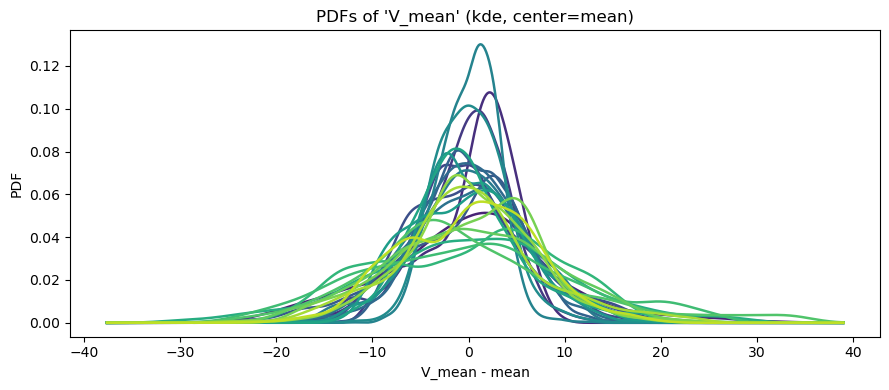

In [9]:
fig, ax, stats_df = list_maps_plots.plot_list_pdfs_circles(
    dfs_obs,
    col="V_mean",
    center="mean",
    method="kde",
    cmap="viridis",
    legend_mode="none",
    annotate=False,
    figsize=(9, 4),
    bw_scale=1.0
)

In [10]:
stats_df

,name,N,mean,std,var,xmin,xmax
0,LVM-30Dor-6563_C0,5375,264.567479,9.156835,83.847633,-25.362979,35.294821
1,LVM-30Dor-6563_I1,5002,268.972657,4.995019,24.950212,-19.362757,10.227443
2,LVM-30Dor-6563_I2,4832,269.243092,4.395217,19.317932,-16.351192,22.033408
3,LVM-30Dor-6563_I3,5077,267.238864,5.777425,33.378644,-17.886464,21.170336
4,LVM-30Dor-6563_I4,4555,270.062148,6.494383,42.177006,-18.037248,27.571952
5,LVM-30Dor-6563_I5,4301,265.190798,7.549164,56.989880,-25.262898,33.630002
6,LVM-30Dor-6563_I6,4790,265.478938,4.813773,23.172414,-15.860238,17.729162
7,LVM-30Dor-6563_I7,4607,267.863209,5.494629,30.190948,-21.129109,19.149791
8,LVM-30Dor-6563_I8,4440,269.919370,6.520928,42.522498,-23.182170,23.487130
9,LVM-30Dor-6563_O1,3221,275.008982,5.699385,32.482991,-17.148182,16.274418


In [11]:
dfs_fit['LVM-30Dor-6563']

KeyError: 'LVM-30Dor-6563'

In [12]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.visualization.wcsaxes.patches import SphericalCircle


c0 = SkyCoord.from_name("Tarantula")
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [13]:
name_file = "LVM-30Dor-6563"   # adjust if needed

circles_df = pd.read_csv("fits_ready/circle_catalog.csv")
circles_df["name"] = [f"{name_file}_{lab}" for lab in circles_df["label"]]

In [14]:

circles = []
for _, row in circles_df.iterrows():
    center = SkyCoord(
        ra=row["ra_deg"] * u.deg,
        dec=row["dec_deg"] * u.deg,
        frame="icrs"
    )

    circles.append({
        "name": row["name"],
        "label": row["label"],
        "ring": row["ring"],
        "angle_deg": row["angle_deg"],
        "center": center,
        "ra_deg": row["ra_deg"],
        "dec_deg": row["dec_deg"],
        "radius_arcsec": row["radius_arcsec"],
    })

In [15]:
circles

[{'name': 'LVM-30Dor-6563_C0',
  'label': 'C0',
  'ring': 'center',
  'angle_deg': nan,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (84.675, -69.1)>,
  'ra_deg': 84.675,
  'dec_deg': -69.1,
  'radius_arcsec': 413.0},
 {'name': 'LVM-30Dor-6563_I1',
  'label': 'I1',
  'ring': 'inner',
  'angle_deg': 0.0,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (84.675, -68.87055556)>,
  'ra_deg': 84.675,
  'dec_deg': -68.87055555555555,
  'radius_arcsec': 413.0},
 {'name': 'LVM-30Dor-6563_I2',
  'label': 'I2',
  'ring': 'inner',
  'angle_deg': 45.0,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (85.1264378, -68.93716139)>,
  'ra_deg': 85.1264378029564,
  'dec_deg': -68.93716138661414,
  'radius_arcsec': 413.0},
 {'name': 'LVM-30Dor-6563_I3',
  'label': 'I3',
  'ring': 'inner',
  'angle_deg': 90.0,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (85.31814997, -69.09879695)>,
  'ra_deg': 85.31814997110958,
  'dec_deg': -69.09879695321894,
  'radius_arcsec': 413.0},
 {'name

In [16]:
circles

[{'name': 'LVM-30Dor-6563_C0',
  'label': 'C0',
  'ring': 'center',
  'angle_deg': nan,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (84.675, -69.1)>,
  'ra_deg': 84.675,
  'dec_deg': -69.1,
  'radius_arcsec': 413.0},
 {'name': 'LVM-30Dor-6563_I1',
  'label': 'I1',
  'ring': 'inner',
  'angle_deg': 0.0,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (84.675, -68.87055556)>,
  'ra_deg': 84.675,
  'dec_deg': -68.87055555555555,
  'radius_arcsec': 413.0},
 {'name': 'LVM-30Dor-6563_I2',
  'label': 'I2',
  'ring': 'inner',
  'angle_deg': 45.0,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (85.1264378, -68.93716139)>,
  'ra_deg': 85.1264378029564,
  'dec_deg': -68.93716138661414,
  'radius_arcsec': 413.0},
 {'name': 'LVM-30Dor-6563_I3',
  'label': 'I3',
  'ring': 'inner',
  'angle_deg': 90.0,
  'center': <SkyCoord (ICRS): (ra, dec) in deg
      (85.31814997, -69.09879695)>,
  'ra_deg': 85.31814997110958,
  'dec_deg': -69.09879695321894,
  'radius_arcsec': 413.0},
 {'name

Text(0.5, 1.0, 'Circle regions')

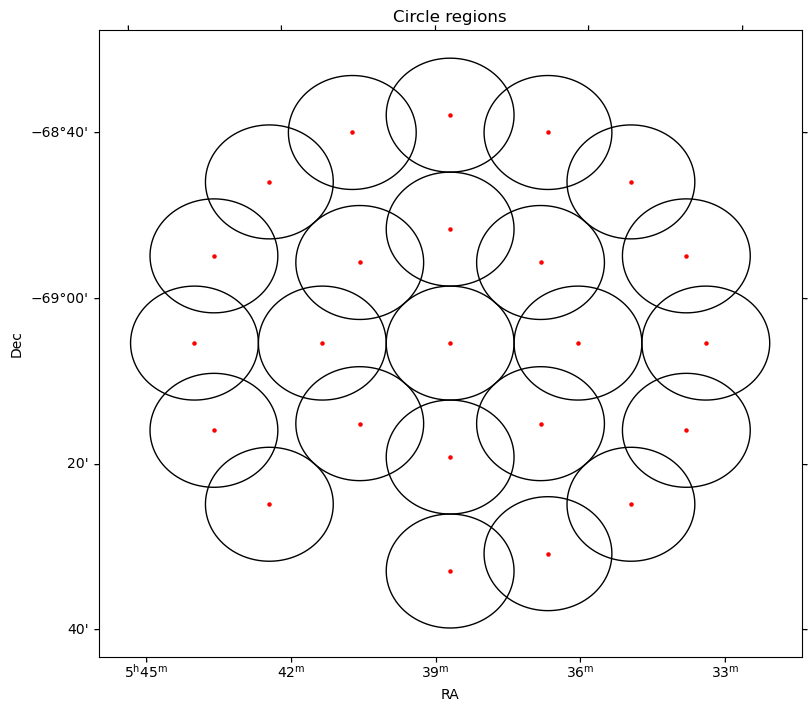

In [17]:
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes.patches import SphericalCircle

fig = plt.figure(figsize=(8, 7), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

for item in circles:
    # draw center point
    ax.scatter(
        item["ra_deg"],
        item["dec_deg"],
        s=5,
        color="red",
        transform=ax.get_transform("world")
    )

    # draw circle
    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1.0,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("Circle regions")

Text(0.5, 1.0, 'Circle regions')

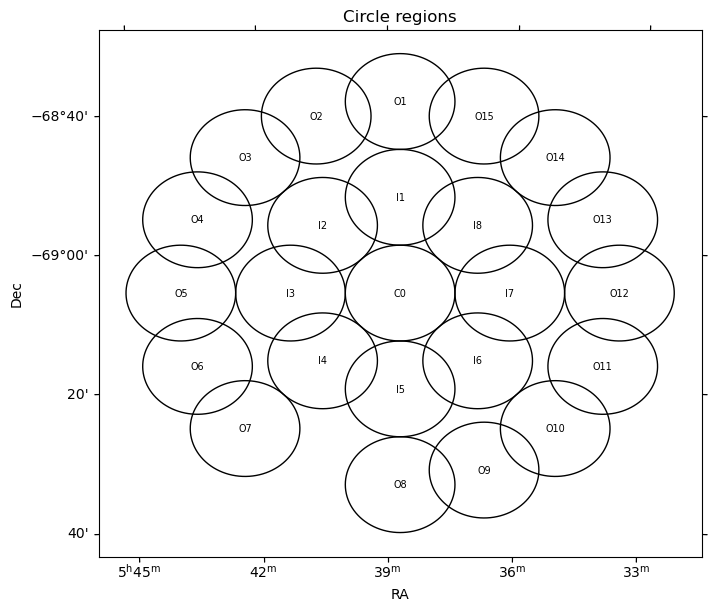

In [18]:
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes.patches import SphericalCircle

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

for item in circles:
    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        item["label"],
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=7,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("Circle regions")

Text(0.5, 1.0, 'sig2 by circle')

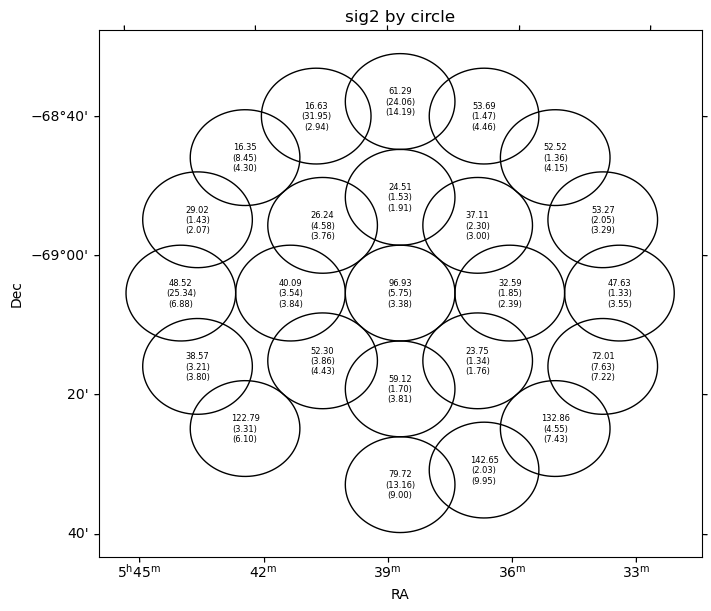

In [19]:
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes.patches import SphericalCircle

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["sig2"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=6,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("sig2 by circle")

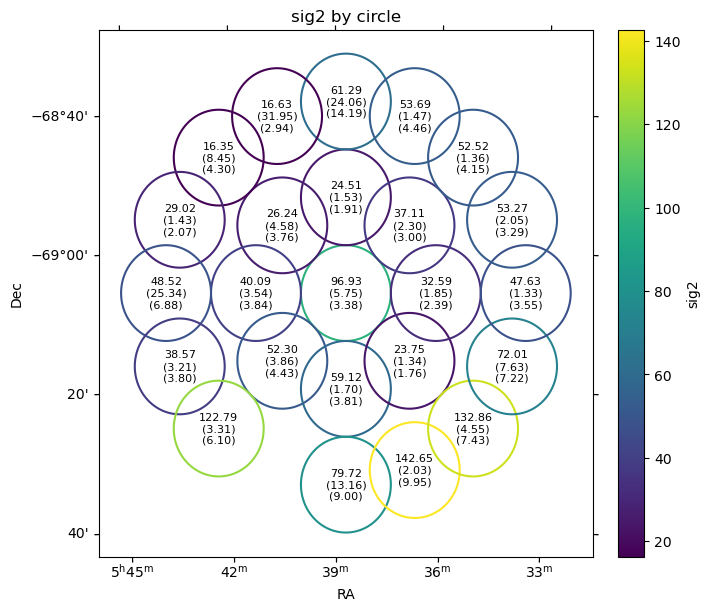

In [20]:
import matplotlib as mpl

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

# values used for the colormap: first row of sig2 in each circle
sig2_main = [dfs_fit[item["name"]]["sig2"].iloc[0] for item in circles]

norm = mpl.colors.Normalize(vmin=min(sig2_main), vmax=max(sig2_main))
cmap = plt.cm.viridis

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["sig2"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    color = cmap(norm(vals[0]))

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor=color,
        facecolor="none",
        linewidth=1.5,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=8,   # bigger text
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("sig2 by circle")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("sig2")

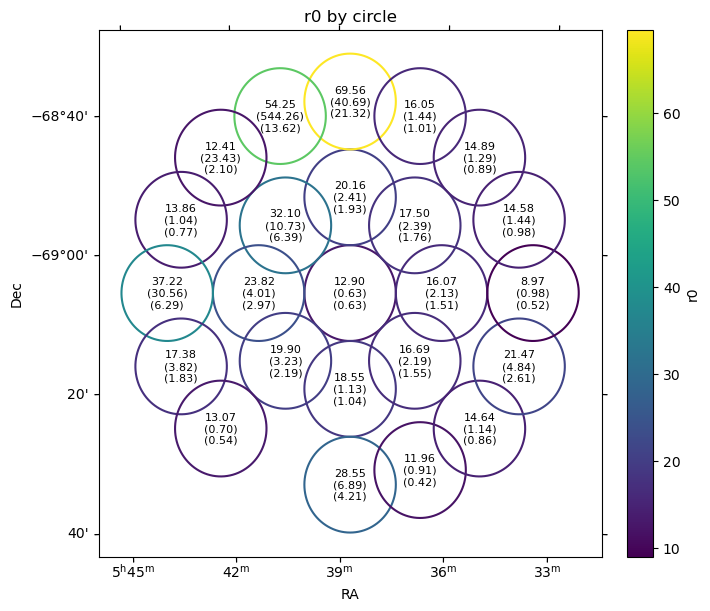

In [21]:
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

r0_main = [dfs_fit[item["name"]]["r0"].iloc[0] for item in circles]

norm = mpl.colors.Normalize(vmin=min(r0_main), vmax=max(r0_main))
cmap = plt.cm.viridis

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["r0"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    color = cmap(norm(vals[0]))

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor=color,
        facecolor="none",
        linewidth=1.5,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=8,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("r0 by circle")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("r0")

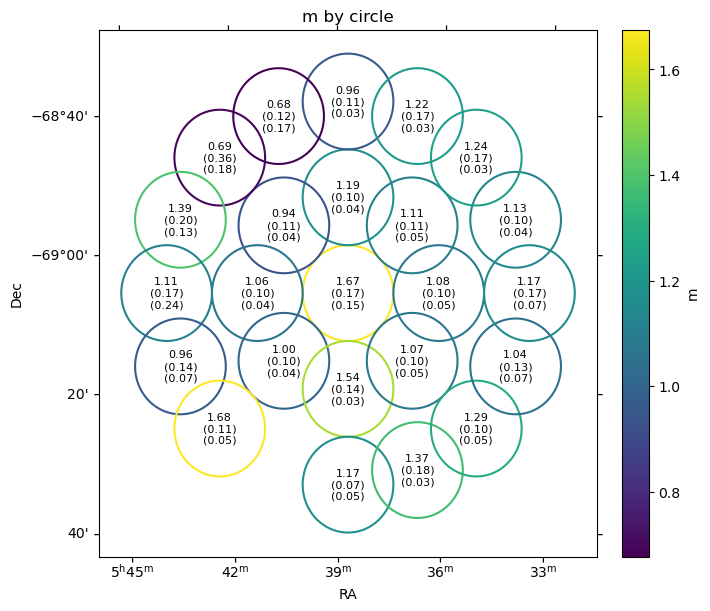

In [22]:
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

m_main = [dfs_fit[item["name"]]["m"].iloc[0] for item in circles]

norm = mpl.colors.Normalize(vmin=min(m_main), vmax=max(m_main))
cmap = plt.cm.viridis

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["m"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    color = cmap(norm(vals[0]))

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor=color,
        facecolor="none",
        linewidth=1.5,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=8,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("m by circle")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("m")